In [1]:
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
from Emmanuel_scheme import Temp_prof,met_profiles,T_v,w_parcel
from kalman_filter_2 import kalman_filter as kf
from sklearn.metrics import mean_squared_error
from scipy.optimize import fsolve,least_squares
from sympy import Symbol, Eq,exp, sqrt, lambdify,Piecewise,Pow
from sympy import exp, sqrt, Max,Min

c:\Users\chari\miniconda3\envs\mude\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
epsilon = 0.622  # unitless
A = 2.5e6  # (J/kg)
B = 2.38e3  # (J/(kg K))
A_1 = 8e-4  # (kg/(m·s²·K^3.5))
A_2 = 2.11e-5  # (m²/s) 
T_star = 273.15  # (K)
p_star = 101325  # (kg/(m·s²))
p_n = 1e5  # (kg/(m·s²))
g = 9.80  # (m/s²)
R = 287  # (J/(kg·K))
R_v = 461  # (J/(kg·K))
c_p = 1004  # (J/(kg·K))
p_l = 2e4  # (kg/(m·s²))
alpha_rain = 3500  # (1/s) for rain
alpha_snow = 1500  # (1/s) for snow
c1_rain = 7e5  # (kg/(m³·s)) for rain
c1_snow = 1.4e5  # (kg/(m³·s)) for snow
C_1 = c1_rain
alpha = alpha_rain

alpha_vel = 0.62
b_vel = 1
# storm invariant parameters from Georgakakos 1986
epsilon_1 = 1.65e-3  # unitless
epsilon_2 = 5e4  # (kg/(m/s²))
epsilon_3 = 1  # (s/m)
epsilon_4 = 0.2e-3  # (m)
gamma = 0.8  # unitless
beta = 0.5  # unitless
m = 0  # unitless
delta = 1/3*(1/gamma + 1/gamma**2 + 1/gamma**3)
g = 9.81

In [3]:
time_str = "2024-07-09 15:00:00"
slice_str = "2024-07-05 19:59:00, 2024-07-07 19:59:00"
slice_tuple = tuple(slice_str.split(", "))

#cabaw_2 = xr.open_mfdataset(r'C:\Users\chari\Downloads\20240709_cabauw_mwr-multi.nc')
measurements= xr.open_mfdataset(r'C:\Users\chari\Home\TU Delft\TU-Delft\thesis\rainmodel_conc\cesar_surface_meteo_lc1_t10_v1.0_202407.nc')
#cabaw_2

#var = ['temperature','pressure','humidity','rain_rate']
var = ['TA002','P0','TD002','RH002'] #temperature, pressure, dew point temperature, relative humidity at 2m height
measurements = measurements[var]
measurements = measurements.dropna(dim='time',how='any')
measurements_used = measurements.sel(time=slice(*slice_tuple))

In [4]:
##cabaw_2 = xr.open_mfdataset(r'C:\Users\chari\Downloads\20240709_cabauw_mwr-multi.nc')
#cabaw_2.equivalent_potential_temperature.sel(time='2024-07-09 15:00:00',method='nearest').plot()
#cabaw_2

In [5]:
parsivel_1 = xr.open_dataset(r'C:\Users\chari\Home\TU Delft\TU-Delft\thesis\rainmodel_conc\data\Cabaw_parsivel\PAR001_Cabauw_202407.nc')
reference_date = np.datetime64("1970-01-01")
datetime_values = reference_date + parsivel_1.epoch_time.astype("timedelta64[s]")
parsivel_1['time'] = datetime_values
rain_rate = parsivel_1.rainfall_rate_32bit.sel(time=measurements_used.time,method='nearest')

In [6]:
#my_temp = cabaw_temp
my_temp = measurements_used.TA002
#press = 100000/np.exp(g*cabaw_temp.height/R/my_temp)
press = measurements_used.P0
#RH = cabaw_2.relative_humidity
#T_surf_C = #my_temp[:,0] - 273.15

#alpha_T = np.where(
    #RH < 1,
    #17.27 * T_surf_C / (T_surf_C + 237.7) + np.log(RH),
    #17.27*T_surf_C/(T_surf_C + 237.7) + np.log(RH/100)  # or 0, or some other value when RH >= 1
#)

    
#T_d= 237.7*alpha_T/(17.27 - alpha_T) + 273.15      #[K]
T_d = measurements_used.TD002

In [7]:
import numpy as np
from scipy.optimize import fsolve
from sympy import Symbol, Eq,exp, sqrt, lambdify

R_d = 287.05
epsilon = 0.622 
A_1 = 8e-4  # (kg/(m·s²·K^3.5))
A = 2.5e6  # (J/kg)
B = 2.38e3  # (J/(kg K))
cp = 1001
p_n = 1e5  # (kg/(m·s²))
def w(T,P):
    #mixing ratio
    return epsilon*A_1*(T - 223.15)**3.5/P
def e_s(T):
    T_C = T - 273.15  # convert to Celsius
    return np.where(
        T >= 273.15,
        np.exp(34.494 - 4924.99 / (T_C + 237.1)) / (T_C + 105) ** 1.57,
        np.exp(43.494 - 6545.8 / (T_C + 278)) / (T_C + 868) ** 2
    )
def w_sat(T,P):
    e_sat = e_s(T)
    return 0.622*e_s(T)/(P- e_sat)


def L(T):
    #latent heat of condensation
    return A - B*(T - 273.15)

#def met_profiles(T_surf,p_surf,p_t):
    p_air = np.linspace(p_surf, p_t, 1000)
    T_air = T_surf*(p_air/p_surf)**0.286
    return p_air, T_air

#def Temp_prof(T_surf,p_surf,T_d,p_air,T_air):

    p_s = (1/((T_surf - T_d)/223.15 + 1))**3.5 * p_surf
    print(p_s)
    T_s = (1/((T_surf - T_d)/223.15 + 1))* T_surf
    print(T_s)
    theta_moist_parcel = T_s*(p_n/p_s)**0.286*np.exp(L(T_s)*w(T_s,p_s)/(cp*T_s))
    theta_dry = T_surf*(p_n/p_surf)**0.286
    #theta_moist_parcel = T_surf*(1e5/p_surf)**(0.2854*(1-0.28*1e-3*w(T_d,p_surf)))*np.exp((3.376/T_s - 0.00254)*w(T_d,p_surf)*(1+0.81*1e-3*w(T_d,p_surf)))
    print(theta_moist_parcel)
    lcl_index = (np.abs(p_air - p_s)).argmin()
    T_arr = theta_dry*(p_air/p_n)**0.286*np.ones(len(T_air))
    #T_arr[lcl_index] = T_s

    for i in range(lcl_index,len(p_air)):
        #print(i)
        T_parcel = Symbol('T_parcel')
        T_func = Eq(theta_moist_parcel,T_parcel * (p_n / p_air[i])**0.286 * exp((A - B * (T_parcel - 273.15)) * (epsilon*A_1*abs(T_parcel - 223.15)**3.5/(p_air[i])) / (cp * T_parcel)))
        T_solve = lambdify(T_parcel, T_func.lhs - T_func.rhs, 'numpy')
        T_parcel = fsolve(T_solve, T_arr[i-1])
        T_arr[i] = T_parcel

    return T_arr,lcl_index

In [8]:

    
e_s_version2 = e_s(my_temp)

def e_s_2(T):
    #saturation vapor pressure
    return A_1*(T - 223.15)**3.5

e_s_version1 = e_s_2(my_temp)   

def e_s_symbolic(T):
    T_C = T - 273.15
    return Piecewise(
        (exp(34.494 - 4924.99 / (T_C + 237.1)) /Pow(T_C + 105, 1.57), T >= 273.15),
        (exp(43.494 - 6545.8 / (T_C + 278)) / Pow(T_C + 868, 2), T < 273.15)
    )

def w_sat_symbolic(T, P):
    e_sat = e_s_symbolic(T)
    return 0.622 * e_sat / (P - e_sat)

In [9]:
class variables:
    def __init__(self, T_0, T_d, p_0,obs):
        self.T_0 = T_0
        self.T_d = T_d
        self.p_0 = p_0
        self.obs = obs
        self.p_s, self.T_s = self.calculate_cloud_base()
        self.Theta_e = self.calculate_Theta_e(self.T_s,self.p_s)
        
    def calculate_cloud_base(self):
        # cloud base pressure, temperature
        p_s = (1/((self.T_0 - self.T_d)/223.15 + 1))**3.5 * self.p_0
        T_s = (1/((self.T_0 - self.T_d)/223.15 + 1))* self.T_0
        return p_s, T_s
    

    def calculate_Theta_e(self, T_s, p_s):
        # equivalent potential temperature inside the cloud
        Theta_e = T_s*(p_n/p_s)**0.286*np.exp(L(T_s)*w(T_s,p_s)/(c_p*T_s))
        return Theta_e
#--------------------------------------------------------------------------------------------------------------------------
    def calculate_cloud_top(self,T_0,p_0,p_s,T_s,Theta_e):
        if self.obs:
            #if they are available from observations, obs=True
            T_t = T_t
            p_t = p_t
        else:
            p_t = Symbol('p_t')
            T_m = Symbol('T_m')
            T_t = Symbol('T_t')

#---------------------------------------------------------------------------------------------------------------------------------------------------------------------
            # solve the two equation system for T_m and p_t

            #  equation for parametrization of cloud top pressure with v_updr and constants
            f1 = Eq(p_t, p_l + (epsilon_2 - p_l) / (1 + epsilon_3 * epsilon_1 *sqrt(Max(1e-7,c_p * (T_m - T_0 / (p_0/(3/4 * p_s + 1/4 * p_t))**0.286)))))
            # equation for solving Theta_e for T_m
            f2 = Eq(Theta_e,T_m * (p_n / (3/4 * p_s + 1/4 * p_t))**0.286 * exp((A - B * (T_m - 273.15)) #replaced L(T) with the whole expression for fsolve
                                * (w_sat_symbolic(T_m,3/4*p_s + 1/4*p_t))/ (c_p * T_m)) ) 

            # Convert the symbolic equations to numerical functions using lambdify
            f1_func = lambdify((p_t, T_m), f1.lhs - f1.rhs, modules='numpy')
            f2_func = lambdify((p_t, T_m), f2.lhs - f2.rhs, modules=[{"e_s": e_s}, "numpy"])

            # Define the system of equations for fsolve
            def system(vars):
                p_t_val, T_m_val = vars
                return np.array([f1_func(p_t_val, T_m_val), 
                        f2_func(p_t_val, T_m_val)])

            # Set your initial guesses
            if p_s>50000:
                initial_guesses = [50000, T_s]
                print('yes')  
            else:
                initial_guesses = [(p_s+20000)/2,245]
            bounds_lower = [20000, 223.15]
            bounds_upper = [p_s, T_s]
            # Solve the system using fsolve
            solution = least_squares(system, initial_guesses, bounds=(bounds_lower, bounds_upper))

            # Extract solution
            p_t, T_m = solution.x
#-------------------------------------------------------------------------------------------------------------------------------------------------------------------------
            # solve the non-linear equation for T_t
            f3 = Eq(Theta_e,T_t * (p_n / p_t)**0.286 * exp((A - B * (T_t - 273.15)) * (w_sat_symbolic(T_t,p_t)) / (c_p * T_t)))
            f3_func = lambdify(T_t, f3.lhs - f3.rhs, 'numpy')
            T_t = fsolve(f3_func, 240)

            # find the ambient air temperature and pressure
            p_s_up = 3/4 * p_s + 1/4 * p_t  #p_s'
            T_s_up = T_0 / (p_0/(p_s_up))**0.286 #T_s'

        return p_t, T_m, T_t,T_s_up, p_s_up
#--------------------------------------------------------------------------------------------------------------------------
    def run(self):
        p_s,T_s = self.p_s,self.T_s
        p_t, T_m, T_t,T_s_up, p_s_up = self.calculate_cloud_top(self.T_0,self.p_0,self.p_s,self.T_s,self.Theta_e)
        return p_s,T_s,p_t, T_m, T_t,T_s_up, p_s_up,self.Theta_e

In [10]:
p_0 = press.values*100#[0].values
T_0 = my_temp.values#my_temp[:,0].values
T_d_arr = T_d.values#T_d[:,0]
T_t_arr = np.zeros(len(T_d_arr))
for i in range(len(T_d_arr)):
    T_d_val = T_d_arr[i]
    T_0_val = T_0[i]
    p_0_val = p_0[i]
    p_s,T_s,p_t, T_m, T_t,T_s_up, p_s_up,Theta_e = variables(T_0_val, T_d_val, p_0_val, False).run()
    T_t_arr[i] = T_t
    print(T_t)

    

yes
[252.80046421]
yes
[252.78633209]
yes
[252.80621103]
yes
[252.81382172]
yes
[252.75016147]
yes
[252.8008185]
yes
[252.81569583]
yes
[252.73120151]
yes
[252.61587941]
yes
[252.45360164]
yes
[252.23164039]
yes
[252.11716414]
yes
[252.00311262]
yes
[251.8354105]
yes
[251.81719145]
yes
[252.02374632]
yes
[252.22361664]
yes
[252.58390603]
yes
[252.67116431]
yes
[252.72135497]
yes
[252.68129856]
yes
[252.76176031]
yes
[252.84351843]
yes
[252.8366685]
yes
[252.67787824]
yes
[252.59843376]
yes
[252.7462876]
yes
[252.78626941]
yes
[252.40673888]
yes
[252.17983368]
yes
[252.0303226]
yes
[252.1411501]
yes
[252.2032596]
yes
[251.84005988]
yes
[251.31588261]
yes
[251.20477768]
yes
[251.40476957]
yes
[251.51067207]
yes
[251.52656635]
yes
[251.71233923]
yes
[251.48861031]
yes
[251.37459151]
yes
[251.47335769]
yes
[251.80457987]
yes
[252.01994979]
yes
[252.2943635]
yes
[252.51418983]
yes
[252.70511027]
yes
[252.80825522]
yes
[252.89159181]
yes
[252.84895638]
yes
[252.85071953]
yes
[252.79345846]
y

KeyboardInterrupt: 

In [ ]:
p_0

array([100600., 100600., 100590., 100590., 100570., 100570., 100560.,
       100550., 100540., 100540., 100520., 100500., 100480., 100470.,
       100460., 100440., 100430., 100420., 100400., 100380., 100360.,
       100330., 100320., 100300., 100280., 100280., 100280., 100270.,
       100240., 100220., 100190., 100190., 100200., 100170., 100160.,
       100150., 100140., 100130., 100130., 100120., 100100., 100090.,
       100080., 100070., 100050., 100050., 100030., 100010., 100000.,
        99980.,  99960.,  99930.,  99920.,  99920.,  99910.,  99900.,
        99890.,  99880.,  99870.,  99860.,  99850.,  99840.,  99830.,
        99830.,  99830.,  99830.,  99830.,  99830.,  99830.,  99820.,
        99810.,  99830.,  99830.,  99820.,  99820.,  99830.,  99830.,
        99830.,  99830.,  99830.,  99830.,  99830.,  99840.,  99850.,
        99860.,  99870.,  99870.,  99880.,  99880.,  99880.,  99900.,
        99920.,  99920.,  99920.,  99930.,  99950.,  99970.,  99970.,
        99980., 1000

In [ ]:
T_0

array([289.75   , 289.72998, 289.76   , 289.87   , 289.87   , 289.88   ,
       289.94   , 289.97   , 289.87   , 289.69   , 289.53998, 289.47998,
       289.36   , 289.19998, 289.13998, 289.25   , 289.41   , 289.75998,
       289.85   , 289.9    , 289.81   , 289.88   , 290.00998, 289.93   ,
       289.77   , 289.66998, 289.83   , 289.79   , 289.47998, 289.25   ,
       289.07   , 289.13998, 289.13998, 288.82   , 288.41998, 288.34   ,
       288.44998, 288.55   , 288.56   , 288.59   , 288.44   , 288.32   ,
       288.41   , 288.69   , 288.86   , 289.11   , 289.3    , 289.44998,
       289.61   , 289.66998, 289.65   , 289.66998, 289.75   , 289.84   ,
       289.94998, 289.91998, 289.9    , 290.07   , 290.28   , 290.41998,
       290.38998, 290.49   , 290.59   , 290.68   , 290.85   , 291.     ,
       291.05   , 291.06   , 291.25998, 291.49   , 291.68   , 291.63998,
       291.82   , 291.91998, 291.66998, 290.91   , 290.83   , 291.09   ,
       291.00998, 291.16   , 291.11   , 291.07   , 

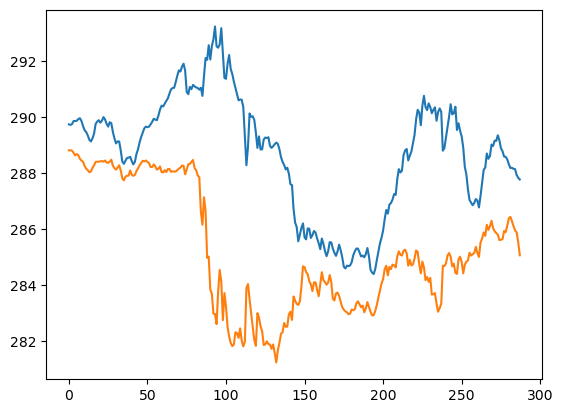

In [ ]:


t = np.arange(0,len(T_d_arr),1)
plt.plot(t,T_0)
plt.plot(t,T_d_arr)
plt.show()

#### 2nd Part

In [ ]:
def v(T_m,T_s_up):
    #average updraft velocity
    v = epsilon_1*np.sqrt(c_p*max(0,(T_m - T_s_up)))
    return v

def rho_m(T_s,T_t,p_s,p_t):
    #average density inside the cloud
    rho_m = (p_s/(R*T_s) + p_t/(R*T_t))/2
    return rho_m


# In[64]:


def f(T_d,p_0,p_t,T_t,rho,v):
    # from Georgakakos 1984a - moisture input flux equation
    #specific humidity (mixing ratio) in the ground and cloud base
    w_0 = w_sat(T_d,p_0)
    w_s = w_sat(T_t,p_t)

    return (w_0 - w_s)*rho*v
    


# In[65]:


def cloud_heights(T_s,T_t,T_0,p_s,p_t,p_0):
    #cloud depth
    Z_c = R*(T_s + T_t)/(2*g)*np.log(p_s/p_t)
    #cloud base height
    Z_b = R*(T_s + T_0)/(2*g)*np.log(p_0/p_s)

    return Z_c,Z_b

    


# In[66]:


def non_dim_numbers(v):
    
    V_p = 4*alpha*epsilon_4*v**m
    N_v = beta*v**(1-m)/(alpha*epsilon_4)
    return V_p,N_v


In [ ]:
class h_out:
    # from Georgakakos 1984a - moisture output flux equation
    def __init__(self,v,Z_c):
        self.V_p = non_dim_numbers(v)[0]
        self.N_v = non_dim_numbers(v)[1]
        self.Z_c = Z_c
        self.O_b = self.O_b()
        self.O_t = self.O_t()
        
    #cloud bottom outflow
    def O_b(self):
        return (1 + 3/4*self.N_v + self.N_v**2/4 + self.N_v**3/24)/np.exp(self.N_v)

    #cloud top outflow 
    def O_t(self):
        return(1 + 3/4*(gamma*self.N_v) + (gamma*self.N_v)**2/4 + (gamma*self.N_v)**3/24)\
                                        /(gamma**5*np.exp(gamma*self.N_v)) + self.N_v/(4*gamma**4) + 1/gamma**5

    #total outflow
    def h_v(self):
        return self.V_p/(self.Z_c*delta)*(self.O_b)#(self.O_t/10 + self.O_b)

    def run(self):
        return self.O_b,self.O_t,self.h_v()


# In[69]:


class phi:
     #state translation to precipitation equation Φ
     def __init__(self, T_0, p_0, T_d, Z_b, Z_c,v):
        self.T_0 = T_0
        self.p_0 = p_0
        self.T_d = T_d
        self.Z_b = Z_b
        self.V_p = non_dim_numbers(v)[0]
        self.Z_c = Z_c
        self.N_v = non_dim_numbers(v)[1]
        self.v = v
        self.O_b = h_out(v, Z_c).O_b
        self.T_w = self.solve_Tw()

     def equation_Tw(self, T):
        #wet bulb temperature
         return T + L(self.T_0)/c_p*(w_sat(T,self.p_0) - w_sat(self.T_d,self.p_0)) - self.T_0
     
     def solve_Tw(self):
        #numerical solution of wet bulb temperature
         T_w_initial = 280
         return fsolve(self.equation_Tw, T_w_initial)
     
      
     def calculate_phi(self):

        #diffusivity of water vapor in air
        D_AB = A_2*(self.T_0/T_star)**1.94*(p_star/self.p_0)

        #critical diameter for evaporation
        D_c = (1/C_1*4*D_AB/R_v*self.Z_b*(e_s(self.T_w)/self.T_w - e_s(self.T_d)/self.T_0))**(1/3)

        # non-dimensional number indicative of diffusional (evaporation) losses of droplets
        N_D = D_c/(epsilon_4*self.v**m)

        #calculating phi
        if (N_D/self.N_v) >=1:
            phi_t = self.V_p/(self.Z_c*delta)* ((1 - self.N_v/4)*(1 + N_D + N_D**2/2) + N_D**3/8) / np.exp(N_D)
        else:
            phi_t = self.V_p/(self.Z_c*delta)*(self.O_b - 1/24*N_D**3/ np.exp(self.N_v))

        return phi_t

In [ ]:
v_arr = np.zeros(len(T_0))
O_b_arr = np.zeros(len(T_0))
O_h_arr = np.zeros(len(T_0))
I_arr = np.zeros(len(T_0))
Z_b_arr = np.zeros(len(T_0))
Z_c_arr = np.zeros(len(T_0))
T_m_arr = np.zeros(len(T_0))
T_t_arr = np.zeros(len(T_0))
p_t_arr = np.zeros(len(T_0))
p_s_arr = np.zeros(len(T_0))
Theta_e_arr = np.zeros(len(T_0))
p_t_arr = np.zeros(len(T_0))
f_arr = np.zeros(len(T_0))  
h_arr = np.zeros(len(T_0))
P = np.zeros(len(T_0))
dt = 600
X = 0.2*np.ones(len(T_0))

for i in range(len(T_d_arr)):
    T_d_val = T_d_arr[i]
    T_0_val = T_0[i]
    p_0_val = p_0[i]
    p_s,T_s,p_t, T_m, T_t,T_s_up, p_s_up,Theta_e = variables(T_0_val, T_d_val, p_0_val, False).run()
    p_s_arr[i] = p_s
    p_t_arr[i] = p_t

    rho = rho_m(T_s,T_t,p_s,p_t)
    v_updr = v(T_m,T_s_up)
    v_arr[i] = v_updr
    Z_c,Z_b = cloud_heights(T_s,T_t,T_0_val,p_s,p_t,p_0_val)
    Z_c_arr[i] = Z_c
    Z_b_arr[i] = Z_b
    O_b,O_t,h_v = h_out(v_updr,Z_c).run()   #outflows and sources of water
    print(T_m,T_s_up)
    #print(non_dim_numbers(v_updr)[1])
    O_b_arr[i] = O_b*X[i]*non_dim_numbers(v_updr)[0]/Z_c
    O_h_arr[i] = O_t*X[i]*non_dim_numbers(v_updr)[0]/Z_c/10
    I_arr[i] = f(T_d_val,p_0_val,p_t,T_t,rho,v_updr)

    f_arr[i] = f(T_d_val,p_0_val,p_t,T_t,rho,v_updr)    #moisture input
    h_arr[i] = h_out(v_updr,Z_c).run()[2]
    if i<(len(T_d_arr)-1):
        X[i+1] = max(0,X[i] + f_arr[i]*dt - h_arr[i]*X[i]*dt)
    P[i] = phi(T_0_val, p_0_val, T_d_val, Z_b, Z_c,v_updr).calculate_phi()*X[i]
    

yes
282.72190323467464 277.07326491417564
yes
282.72503402865306 277.0754847681621
yes
282.70975842915993 277.0624731077689
yes
282.60123846905276 276.96409960815384
yes
282.50015975035456 276.8694305692773
yes
282.5556829678612 276.9221338836482
yes
282.5015663531657 276.8736689378294
yes
282.3493631398967 276.73182031385517
yes
282.29710494928713 276.6792837028011
yes
282.2790881225437 276.6556951854207
yes
282.1322408777896 276.51292837331886
yes
282.0286605785369 276.4142442544222
yes
281.9914473948949 276.3756197094205
yes
281.9365132944562 276.31868009607507
yes
281.9694991609529 276.34768977451307
yes
282.10339746232495 276.47775560169055
yes
282.1827452030746 276.55834429100594
yes
282.26705694799136 276.6507305699327
yes
282.2663514541577 276.6540439166034
yes
282.2603708933952 276.65092104812567
yes
282.28728355030694 276.67348496987626
yes
282.29051437951546 276.6800818103167
yes
282.2485937811071 276.645881350079
yes
282.30821272988294 276.6995403122275
yes
282.254536523302

array([46684.27779441, 46684.03999708, 46684.63103275, 46687.28169871,
       46688.9576677 , 46688.22019104, 46689.69847362, 46692.40923122,
       46692.33630285, 46690.8773395 , 46691.94572611, 46693.2283264 ,
       46692.85853708, 46692.33317227, 46691.29190707, 46690.28870228,
       46690.61349259, 46692.72788871, 46693.78095308, 46694.53003954,
       46693.39019862, 46694.272412  , 46696.29703908, 46694.73386682,
       46694.17951713, 46693.14171506, 46694.3699039 , 46692.6995445 ,
       46692.9327298 , 46691.94911212, 46690.91252904, 46690.45121123,
       46688.91530071, 46688.60714329, 46689.27383899, 46689.76893556,
       46688.58676912, 46689.26176322, 46689.18818664, 46686.19522779,
       46687.37590329, 46686.78320599, 46687.3399108 , 46688.08760684,
       46688.58001536, 46689.56917808, 46690.55536512, 46691.08699525,
       46693.45805676, 46693.79799154, 46694.58501138, 46695.76058305,
       46699.39035117, 46700.50812041, 46700.27707666, 46701.27183912,
      

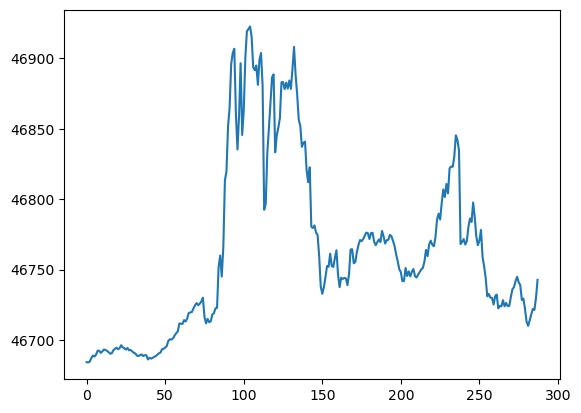

In [ ]:
#plt.plot(t,T_t_arr)
#plt.plot(t,p_s_arr)
plt.plot(t,p_t_arr)
p_t_arr
#plt.ylim(0,50000)

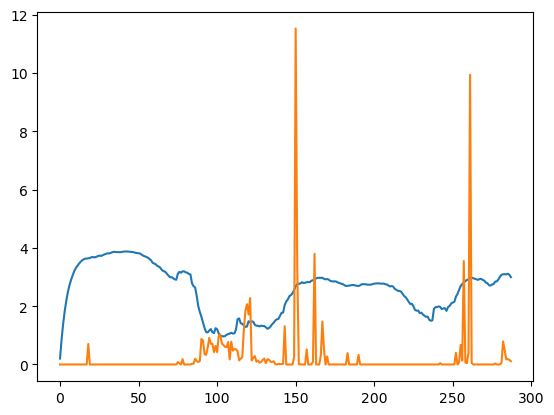

In [ ]:
t1 = np.arange(0,len(rain_rate),1)
plt.plot(t,P*3600)
plt.plot(t1,rain_rate)

In [ ]:
np.min(p_s_arr)

85351.40899990973

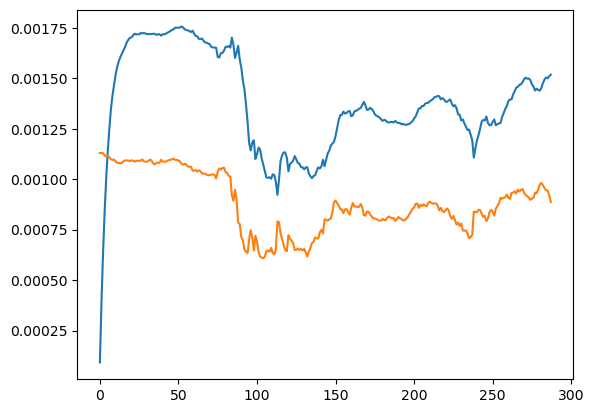

In [ ]:
plt.plot(t,O_b_arr)
#plt.plot(t,O_h_arr)
plt.plot(t,I_arr)
